About the homework: In some tasks, in addition to writing code, answers to questions and conclusions are required (there are special Markdown cells marked with **Answer**).

The ability to analyze the results of experiments is an important skill. Therefore, answers carry more weight than the code: the code accounts for 30% of the task grade, while answers to questions account for 70%.

**Reminder:** Plagiarism is prohibited. Use of AI without mentioning how and in which parts it was used is also prohibited. If plagiarism or dishonest use of AI is revealed, the assignment is graded with 0.

In [58]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

Let's work with data about students.

In [60]:
!wget --no-check-certificate https://raw.githubusercontent.com/Majid-Sohrabi/DAM-2024/refs/heads/main/07-trees/students.csv
# I use --no-check-certificate in order to keep my Kaspersky antivirus working.

--2024-12-08 23:50:18--  https://raw.githubusercontent.com/Majid-Sohrabi/DAM-2024/refs/heads/main/07-trees/students.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.111.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
  Self-signed certificate encountered.
HTTP request sent, awaiting response... 200 OK
Length: 126614 (124K) [text/plain]
Saving to: 'students.csv'

     0K .......... .......... .......... .......... .......... 40% 43.5M 0s
    50K .......... .......... .......... .......... .......... 80% 49.1M 0s
   100K .......... .......... ...                             100% 60.3M=0.003s

2024-12-08 23:50:19 (48.3 MB/s) - 'students.csv' saved [126614/126614]



In [61]:
df = pd.read_csv('students.csv')


df.sample(4)

,ID,Performance Index,Previous Scores (out of 10),Sample Question Papers Practiced,Hours Studied,Hours Prepared for Exams,Hours Free time,Sleep Hours,Hours Not Sleep,Extracurricular Activities,Has a car,Sex,Height,Weight,BMI,Eye color,Nails length,Favorite Subject,Least Favorite Subject
356,357,60.0,6,8,6,3,12,4,20,Yes,No,m,1.667174,78.663529,28.301631,brown,0.005316,Art,Data Science
16,17,46.0,6,7,4,2,11,6,18,Yes,No,m,1.679547,55.260179,19.589715,NaN,0.003335,Algebra,Biology
213,214,62.0,9,2,1,1,14,7,17,No,Yes,f,1.638496,74.399332,27.712649,brown,0.009158,Data Science,Drama
144,145,54.0,6,5,6,3,12,5,19,Yes,Yes,f,1.645202,75.592349,27.927977,gray,0.009628,Art,Art


We will predict their performance index.

In [63]:
X = df.drop(columns=['Performance Index']).drop(columns=['ID']) # Droppind "ID" column since it is useless in our analysis
y = df['Performance Index']

# Task 1 (2 points)

Let's try to propose hypothesis, which features will be the most useful.

For every feature $x^j$:

*   Draw a plot of $x^j$ and target (scatter plot, if feature is numerical and boxplot if the feature is categorical)
*   Compute correlation of  $x^j$ and target if the feature is numerical.



Draw conclusions: which features seems to be the most important? Which do not seem useful? Is it logical?

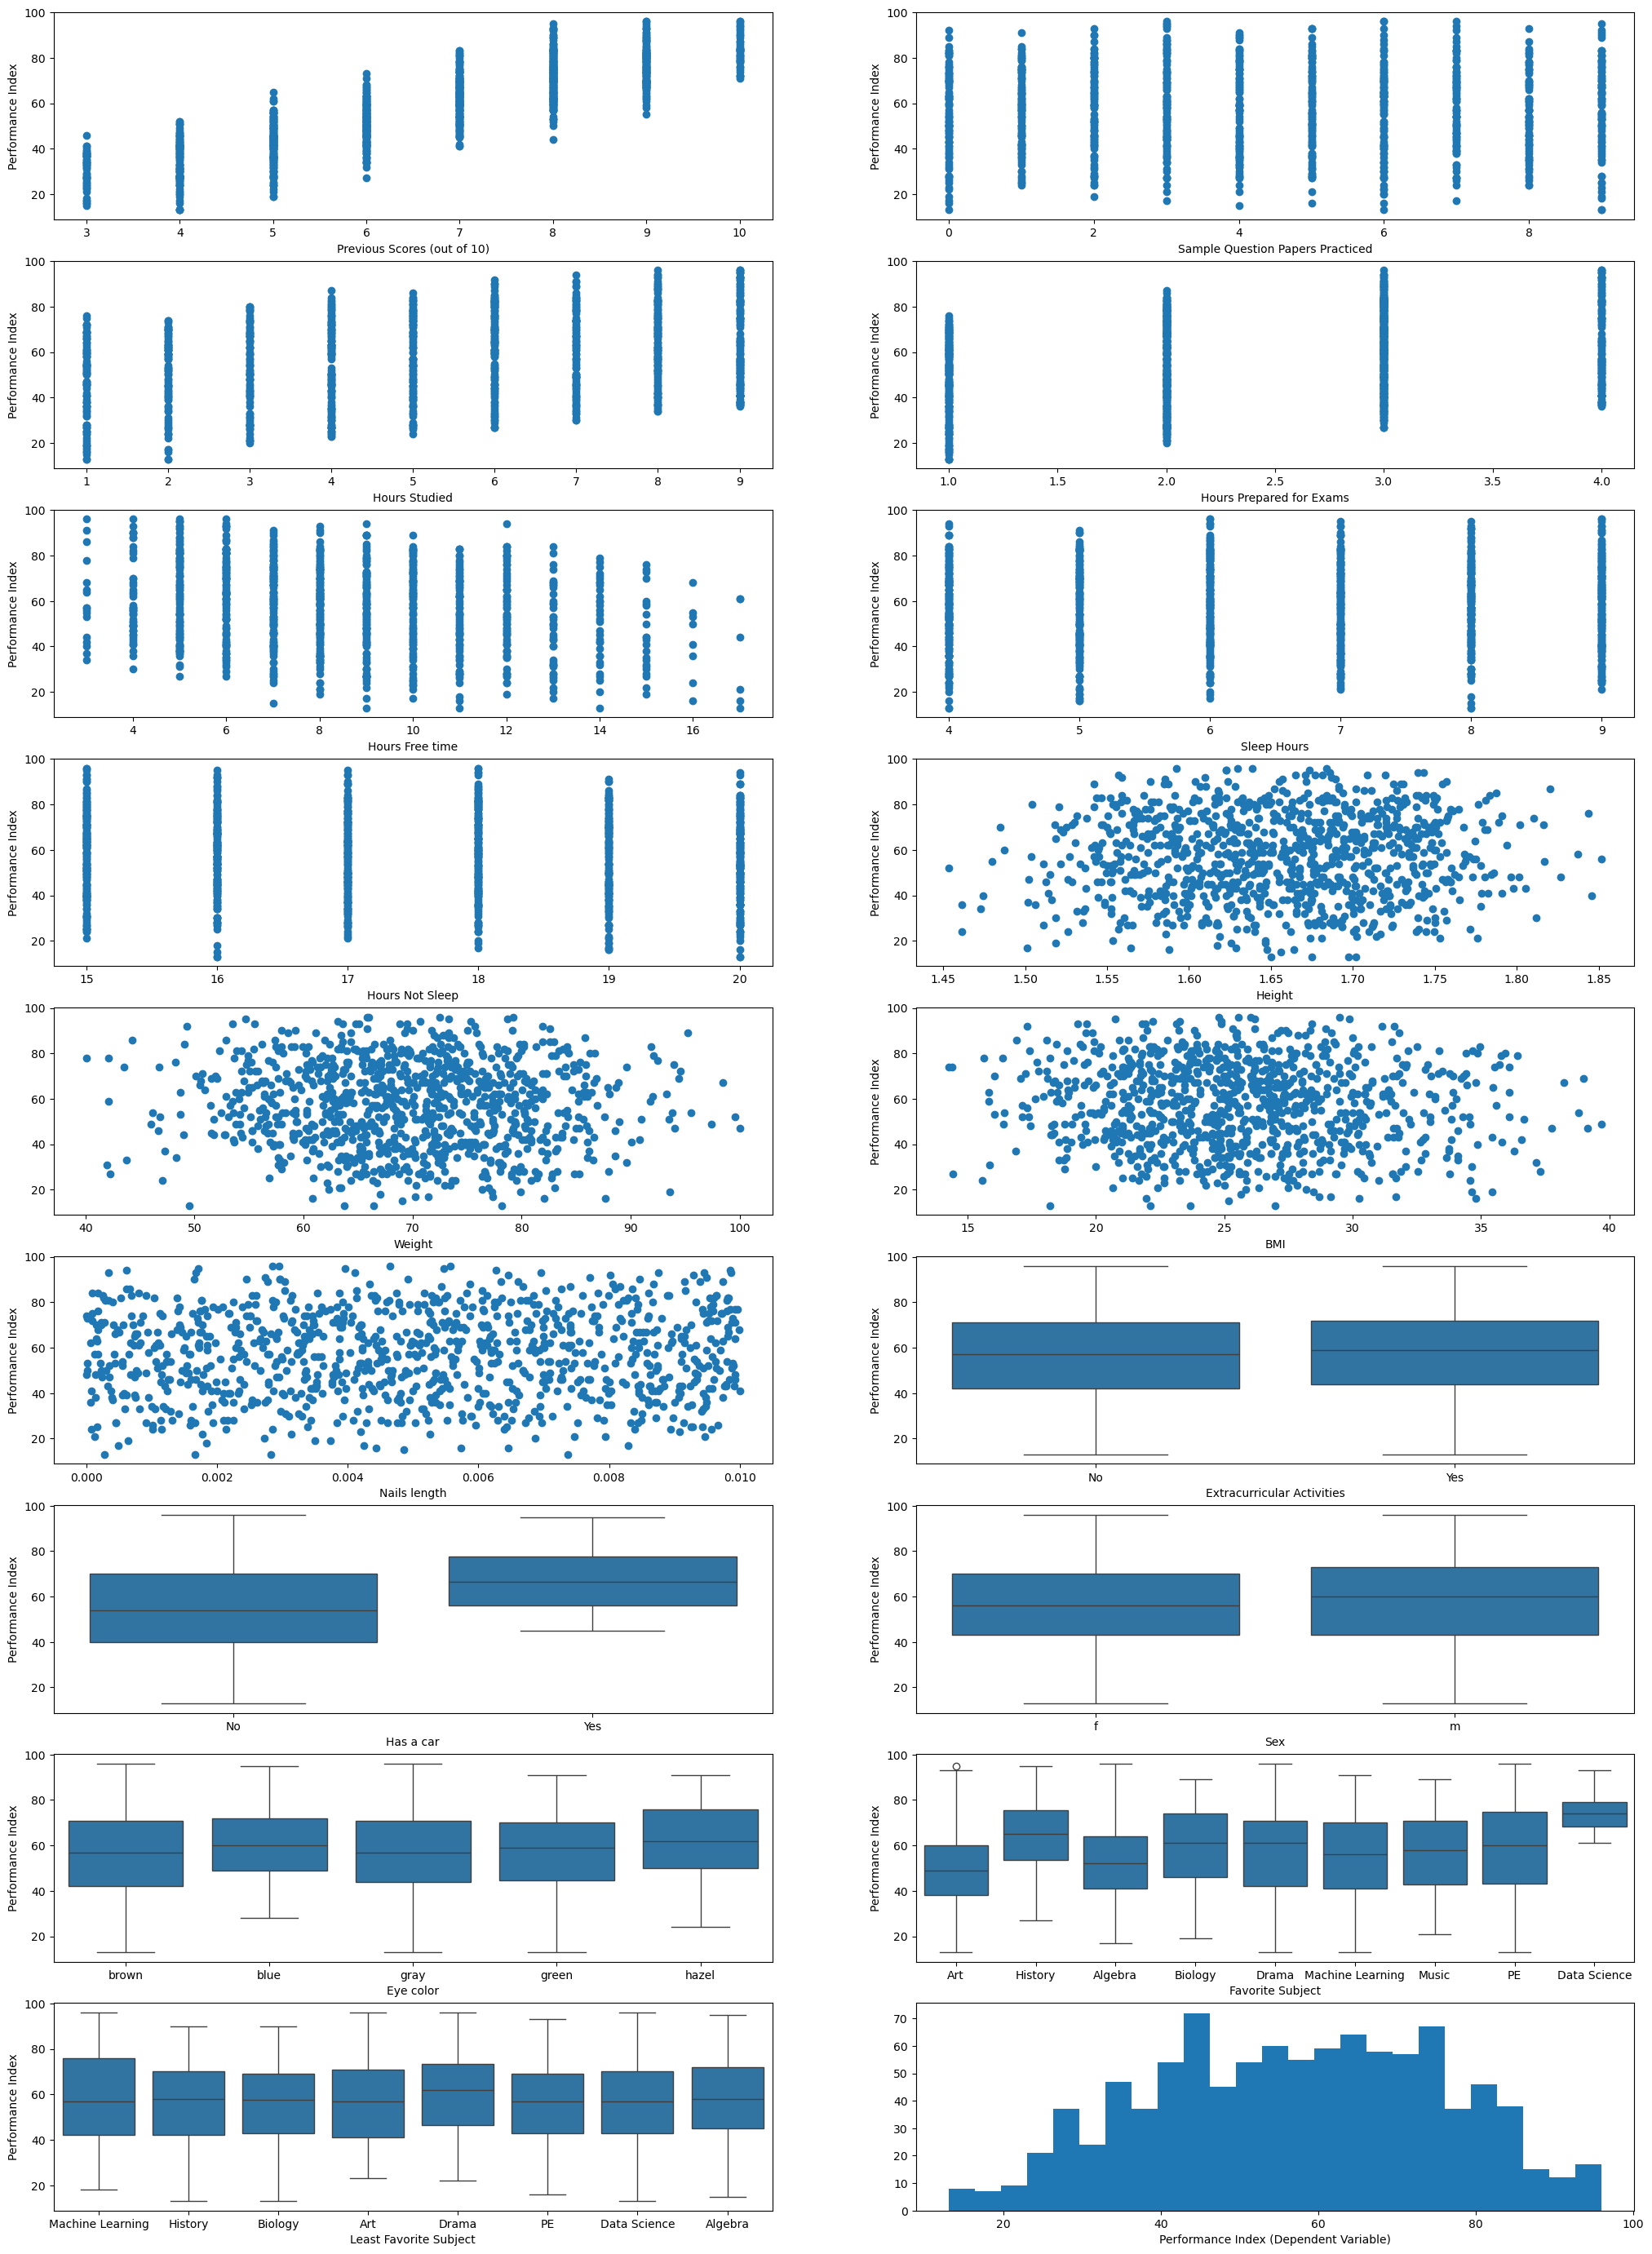

In [67]:
figure, ax = plt.subplots(9, 2, figsize = (25, 35))

ax[0, 0].scatter(X["Previous Scores (out of 10)"], y)
ax[0, 0].set_xlabel('Previous Scores (out of 10)')
ax[0, 0].set_ylabel("Performance Index")

ax[0, 1].scatter(X["Sample Question Papers Practiced"], y)
ax[0, 1].set_xlabel('Sample Question Papers Practiced')
ax[0, 1].set_ylabel("Performance Index")

ax[1, 0].scatter(X["Hours Studied"], y)
ax[1, 0].set_xlabel("Hours Studied")
ax[1, 0].set_ylabel("Performance Index")

ax[1, 1].scatter(X["Hours Prepared for Exams"], y)
ax[1, 1].set_xlabel("Hours Prepared for Exams")
ax[1, 1].set_ylabel("Performance Index")

ax[2, 0].scatter(X["Hours Free time"], y)
ax[2, 0].set_xlabel("Hours Free time")
ax[2, 0].set_ylabel("Performance Index")

ax[2, 1].scatter(X["Sleep Hours"], y)
ax[2, 1].set_xlabel("Sleep Hours")
ax[2, 1].set_ylabel("Performance Index")

ax[3, 0].scatter(X["Hours Not Sleep"], y)
ax[3, 0].set_xlabel("Hours Not Sleep")
ax[3, 0].set_ylabel("Performance Index")

ax[3, 1].scatter(X["Height"], y)
ax[3, 1].set_xlabel("Height")
ax[3, 1].set_ylabel("Performance Index")

ax[4, 0].scatter(X["Weight"], y)
ax[4, 0].set_xlabel("Weight")

ax[4, 1].scatter(X["BMI"], y)
ax[4, 1].set_xlabel("BMI")
ax[4, 1].set_ylabel("Performance Index")

ax[5, 0].scatter(X["Nails length"], y)
ax[5, 0].set_xlabel("Nails length")
ax[5, 0].set_ylabel("Performance Index")

sns.boxplot(x = X["Extracurricular Activities"], y = y, ax = ax[5, 1])

sns.boxplot(x = X["Has a car"], y = y, ax = ax[6, 0])

sns.boxplot(x = X["Sex"], y = y, ax = ax[6, 1])

sns.boxplot(x = X["Eye color"], y = y, ax = ax[7, 0])

sns.boxplot(x = X["Favorite Subject"], y = y, ax = ax[7, 1])

sns.boxplot(x = X["Least Favorite Subject"], y = y, ax = ax[8, 0])

ax[8, 1].hist(y, bins = 25)
ax[8, 1].set_xlabel("Performance Index (Dependent Variable)")

plt.show()

In [68]:
Numerical_vars = ["Previous Scores (out of 10)", "Sample Question Papers Practiced", "Hours Studied", "Hours Prepared for Exams", \
                 "Hours Free time", "Sleep Hours", "Hours Not Sleep", "Height", "Weight", "BMI", "Nails length"]

X_numerical = X[Numerical_vars]

def feature_selector(X_numerical, y, score_function, n_features=5):
    importance_list = []
    feature_names = X_numerical.columns.to_numpy()
    for i in feature_names:
        importance_list.append(score_function(X_numerical[i], y))
    importance_list = [0 if np.isnan(i) else i for i in importance_list]
    best_features = feature_names[np.argsort(importance_list)[-n_features:]][::-1]

    return best_features

def pearson_correlation_abs(X_numerical, y):
  return np.abs(np.corrcoef(X_numerical, y)[0, 1])

cor_features = feature_selector(X_numerical, y, score_function=pearson_correlation_abs)
print(cor_features, "are important features.")

['Previous Scores (out of 10)' 'Hours Studied' 'Hours Prepared for Exams'
 'Hours Free time' 'Hours Not Sleep'] are important features.


**Answer**
To establish whether some independent variables would be important for our analysis, we should consider if some values of dependent variable ("Performance Index") grow or decline with relation to growth in the values of the independent variables for numerical (independent) variables and their scatter plots, and look if the distribution of the dependent variable is different for different values of independent variables for categorical (independent) varaibles as shown on their boxplots. From the plots shown above, the dependent variable values grow with growth of "Previous Scores (out of 10)", "Hours Studied" and "Hours Prepared for Exams" (and, probably, "Sleep Hours", although it is hard to tell precisely solely from the scatter plot), so we can expect that there may be a positive coefficient for these variables when we will conduct linear regression further.This is logical, since indeed hours of study and hours of preparing for exams should influence the performance of the student, and if the student has better scores for previous exams it can be expected that she will in the same manner further; if "Sleep Hours" will turn out to be important too, this would be logical, since amount of sleep influences general performance.  Dependent variable seem to decline with growth of "Hours Free time" (situation similar to "Sleep Hours", variable, which is not surprising, since they are almost interchangeable), and so we may expect negative coefficient for this variable further. It is also logical, since the more time a person spends of leisure the lesser time she has for studying; and if the "Hours not slept" will indeed prove to be important, it would be logical as well, since the less person sleeps the worse her general performance becomes.
Among the categorical variables, "Has a car" and "Favorite Subject" seem to be the most important ones. Performance becomes better is a student has a car, and if her favorite subject is either "History", "Biology", "Drama", and, with a great advantage, "Data Science". For the car possession, this is not surprising, since having a car makes transportation much simpler, and more time and energy is left to studying. For the "Favorite Subject" variable, I cannot really explain the results, but they are still there as a fact; interestingly, those who like Humanitarian and Arts subject have similar performance to those who prefer more natural and precise ones, although "Data Scientist" are generally more performative (which may be useful, since this is a subject now relevant to almost all, if not all, areas of study).
As the last plot, I have created a histogram for the distribution of out dependent variable, which was not required by the task, but was still, I think, interesting to look at. The variable seems to be almost normally distributed, which is logical, due to the usual normality of distribution of similar parameters such as global IQ scores (obviously, not present in the studied dataset; however, it would be also interesing to check if IQ of students significantly influences their performance).
After checking the correlation for numerical variables, we prove our interpretation of the graphs above to be mostly correct. As can be seen from the list of the important variables, "Previous Scores (out of 10)", "Hours Studies", "House Prepared for Exams", "Hours Free time" and "Hours not slept" turn out to be correlated with the dependent variable "Performance Index" and are thus of importance to our investigation. "Sleep hours" turned out to be uncorrelated with the dependent variables, but we unsure about it anyway, since it was hard to tell if it is important solely from the graph.

# Task 2 (3 points)

Split data into train and test. Set `test_size=0.3, random_state=0`

In [72]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

Preprocess the data:


*   Depict number of missing values in every column, replace missing values with median, computed on train data (numerical features) or with 'Not Given' (categorical features)
*   Encode the categorical with one-hot-encoder



In [74]:
from sklearn.preprocessing import OneHotEncoder

Categorical_vars = ["Extracurricular Activities", "Has a car", "Sex", "Eye color", "Favorite Subject", "Least Favorite Subject"]

print(X_test.isna().sum().sort_values(ascending=False))
print(X_train.isna().sum().sort_values(ascending=False))
print(df.isna().sum().sort_values(ascending=False)) # This is to check if the dependent variable contains any 
                                                    # missing values (results show that it doesn't).

values = { "For Categorical": "Not Given", "Median" : X_train[Numerical_vars].median() }

X_test[Categorical_vars] = X_test[Categorical_vars].fillna(values["For Categorical"])
X_test[Numerical_vars] = X_test[Numerical_vars].fillna(values["Median"])
X_train[Categorical_vars] = X_train[Categorical_vars].fillna(values["For Categorical"])
X_train[Numerical_vars] = X_train[Numerical_vars].fillna(values["Median"])

ohe = OneHotEncoder(drop='first')

X_train_categorical_enc = ohe.fit_transform(X_train[Categorical_vars]).toarray()
X_train_cat_enc_df = pd.DataFrame(X_train_categorical_enc, columns = ohe.get_feature_names_out(Categorical_vars))
X_train = pd.concat([X_train.reset_index(drop=True), X_train_cat_enc_df.reset_index(drop=True)], axis = 1)
X_train = X_train.drop(Categorical_vars, axis = 1)

X_test_categorical_enc = ohe.fit_transform(X_test[Categorical_vars]).toarray()
X_test_cat_enc_df = pd.DataFrame(X_test_categorical_enc, columns = ohe.get_feature_names_out(Categorical_vars))
X_test = pd.concat([X_test.reset_index(drop=True), X_test_cat_enc_df.reset_index(drop=True)], axis = 1)
X_test = X_test.drop(Categorical_vars, axis = 1)

print(X_train.shape)
print(X_test.shape)

Favorite Subject                    38
Least Favorite Subject              34
Has a car                           19
Eye color                            8
Hours Prepared for Exams             0
Hours Free time                      0
Sleep Hours                          0
Hours Not Sleep                      0
Extracurricular Activities           0
Sample Question Papers Practiced     0
Sex                                  0
Height                               0
Weight                               0
BMI                                  0
Nails length                         0
Hours Studied                        0
Previous Scores (out of 10)          0
dtype: int64
Favorite Subject                    70
Least Favorite Subject              69
Has a car                           63
Eye color                           28
Weight                               1
BMI                                  1
Hours Prepared for Exams             0
Hours Free time                      0
Sleep Hours 

Train linear regression without regularization, compute MSE on train and test data.

In [76]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

lr = LinearRegression()
regression_train = lr.fit(X_train, y_train)
y_pred  = lr.predict(X_train)
print("MSE for training dataset:", mean_squared_error(y_train, y_pred))

lr = LinearRegression()
regression_test = lr.fit(X_test, y_test)
y_pred_test  = lr.predict(X_test)
print("MSE for testing dataset:", mean_squared_error(y_test, y_pred_test))

MSE for training dataset: 31.822574615478516
MSE for testing dataset: 32.58483115573647


# Task 3 (3 points)

Investigate the coefficients of the model. Why are they so big/small? Can the absolute value of the coefficitnt be used as a measure of importance of the feature? Why/why not?

In [79]:
X_train_and_test_coeffs = pd.DataFrame([ np.concatenate((["Train"], regression_train.coef_), axis = 0),
                            np.concatenate((["Test"], regression_test.coef_), axis = 0) ])
X_train_and_test_coeffs.columns = np.concatenate((["Dataset:"], X_train.columns.to_list()), axis = 0)

print(X_train_and_test_coeffs.iloc[:, 0:20])
print(X_train_and_test_coeffs.iloc[:, 20:38])

  Dataset: Previous Scores (out of 10) Sample Question Papers Practiced  \
0    Train           8.713766400533789             0.005586550885050445   
1     Test           8.903878645247133              0.26591472669322425   

        Hours Studied Hours Prepared for Exams       Hours Free time  \
0   2.752507711336026      0.11719851709661128  -0.06361121473349694   
1  2.5544236074549027      0.49602921476975326  -0.17546163407678012   

           Sleep Hours       Hours Not Sleep              Height  \
0  -1060433160357.4026   -1060433160357.7367  10.359514465167443   
1  0.07195990316979839  -0.07195990316180428  5.0992750195154946   

                 Weight                  BMI        Nails length  \
0   -0.2878210192186111   0.6622767079552689   42.99901947939165   
1  0.010380078886229827  0.11491726878299147  104.51753222124485   

  Extracurricular Activities_Yes  Has a car_Not Given       Has a car_Yes  \
0             1.4323595408648195     1.40599300275875  0.8505035740756

**Answer** For now, the coefficient as results of our regression modelling are written in scientific notation. For the train dataset, some of them are very big, and some of them are quite small. However, there are no extremely small ones, although extremely big ones exist (such as 'Sleep Hours' with coefficient of -1060433160357.4026 and 'Hours Not Sleep' with coefficient of -1060433160357.7367), which does not make any sense, given that "Sleep Hours" and "Hours Not Sleep" are contrary to each other semantically and still have similar negative coefficients, and also since they cannot in general be this big given that our predicted variable is measured in scale from 0 to 100. Among the small ones I would signify 'Sample Question Papers Practiced' with coefficient 0.005586550885050445, that is, smaller than 0.01, and some that are smaller than 0.1 ('Hours Free time', -0.06361121473349694, 'Eye color_hazel', -0.09458230227368315, and 'Favorite Subject_Music', -0.09079237590523291).
However, the value of the coefficient, whether big or small, or positive or negative (or absolute) as such does not allow us to say whether the features are indeed more or less important for us in our analysis. The values of coefficients are important to us only if there is a proven linear relationship between the independent variables in question and the dependent variable. If there is a relationship, then looking at coefficients is valuable. However, both negative and positive coefficient will be importance to us if there is a linear relationship between the independent variables we are looking at and the dependent variable. Negative coefficient measures how much the dependent variable decreases when the independent variable increases by 1 unit, and positive coefficient measure how much the dependent variable increases with increases of independent variable by 1 unit. 

Draw conclusions about the model and important features and explain if it is logical. If it cannot be done right now, tackle the problem.

In [82]:
from sklearn.preprocessing import StandardScaler

feature_names = X_train.columns.to_list()

sc = StandardScaler()

sc.fit(X_train[Numerical_vars])
X_train_numerical_transf = sc.transform(X_train[Numerical_vars])
X_train_numerical_transf = pd.DataFrame(X_train_numerical_transf, columns = sc.get_feature_names_out(Numerical_vars))
X_train = pd.concat([X_train_numerical_transf, X_train.drop(Numerical_vars, axis = 1)], axis=1)

sc.fit(X_test[Numerical_vars])
X_test_numerical_transf = sc.transform(X_test[Numerical_vars])
X_test_numerical_transf = pd.DataFrame(X_test_numerical_transf, columns = sc.get_feature_names_out(Numerical_vars))
X_test = pd.concat([X_test_numerical_transf, X_test.drop(Numerical_vars, axis = 1)], axis=1)

lr = LinearRegression()
regression_train = lr.fit(X_train, y_train)
y_pred  = lr.predict(X_train)
print("MSE for training dataset with scaled numerical:", mean_squared_error(y_train, y_pred))

lr = LinearRegression()
regression_test = lr.fit(X_test, y_test)
y_pred_test  = lr.predict(X_test)
print("MSE for testing dataset with scaled numerical:", mean_squared_error(y_test, y_pred_test), "\n")

X_train_and_test_coeffs = pd.DataFrame([ np.concatenate((["Train"], regression_train.coef_), axis = 0),
                            np.concatenate((["Test"], regression_test.coef_), axis = 0) ])
X_train_and_test_coeffs.columns = np.concatenate((["Dataset:"], feature_names), axis = 0)

print(X_train_and_test_coeffs.iloc[:, 0:20])
print(X_train_and_test_coeffs.iloc[:, 20:38])

cor_features = feature_selector(X_train, y_train, score_function=pearson_correlation_abs)
print(cor_features, "are important features.")

MSE for training dataset with scaled numerical: 31.822596840189018
MSE for testing dataset with scaled numerical: 32.58483115573647 

  Dataset: Previous Scores (out of 10) Sample Question Papers Practiced  \
0    Train           16.44868362952117              0.01862361247387989   
1     Test          15.985706752869534               0.7278468150732804   

       Hours Studied Hours Prepared for Exams       Hours Free time  \
0  7.062300917166978      0.11285351812792144  -0.19187158430708773   
1  6.532951901429449       0.4650227959608607   -0.5342143253135285   

           Sleep Hours      Hours Not Sleep              Height  \
0   0.2868957571922697  -0.2868957571918861  0.7362321236772238   
1  0.12419889231112391  -0.1241988923112734  0.3567376579758812   

                Weight                 BMI         Nails length  \
0  -2.9379395669938484  2.9671276715025208  0.12106171574742765   
1  0.09771272944932735  0.4905530168790666   0.3105515200887068   

  Extracurricular Acti

**Answer** We could not draw conclusions from the coefficients above, since even though the categorical variables were encoded, the numerical ones were neither fitted nor scaled (while they may have extremely different scales of measuring values, which messes the calculations). Standard Scaler from Scikit-learn library allows to fix and scale the numerical variables. After doing the fitting and scaling, coefficients for both numerical and categorical variables start to make sence (as can be seen from the printed output above). Coefficients as such tell us nothing about importance, so it was important from us to conduct a correlation test identical to what we have conducted in the beginning of our homework, but since now our categorical variables are one-hot encoded, they could be also taken into consideration. As can be seen from the code output, the important features are 'Previous Scores (out of 10)', 'Hours Studied', 'Hours Prepared for Exams', 'Hours Free time' and 'Favorite Subject_Data Science' with corresponding coefficients of 16.44868362952117, 7.062300917166978, 0.11285351812792144, -0.19187158430708773, and 2.594758366055326 (these being coefficients for the training dataset). As can be seen, not all of the coefficients are big, such as coefficients for 'Hours Prepared for Exams' (only 0.11285351812792144) and for 'Hours Free time' (only -0.19187158430708773), but they are still important, since the variables are correlated. Correlation does not imply causation, but still means that these are important features to look at. As for the values of coefficients, they make perfect sense: previous score is greatly related to performance, as well as hours of general studying. Hours of preparation for exams are also important and have a positive coefficient, but not as big as that of hours spent on general studying, which is also logical, since knowledge needs time to be better comprehended. Hours of leisure (Hours of free time) is negatively related to performance, which is also not something surprising. About the "Favorite Subject_Data Science" I cannot say much more than what I have said above: Data Science is not relevant in all areas of study and research, and those who like it may do better in their academic and learning pursuits.

# Task 3 (3 points)

For different `alpha` hyperparameter fit linear regression with $L_1$ regularization (`Lasso` model, if there are warnings - set `tol=0.1`).

Choose the grid in such way that the smallest alpha will result in 0-5 zero coefficent and for biggest - all coefficient will be 0.

For every model save number of zero coefficients and MSE on train and test data

In [86]:
from sklearn.linear_model import Lasso

alphas = np.logspace(-4, 3, 10)
coeffs_and_MSEs = pd.DataFrame({ "Alphas": [], "Coefficients train": [], "Coefficients test": [], "MSE train": [], "MSE test": [] })
for alpha in alphas:
    regr_train = Lasso(alpha=alpha, tol = 0.1).fit(X_train, y_train)
    regr_test = Lasso(alpha=alpha, tol = 0.1).fit(X_test, y_test)
    y_pred_train = regr_train.predict(X_train)
    y_pred_test  = regr_test.predict(X_test)
    coefficients_train = regr_train.coef_
    coefficients_test = regr_test.coef_
    for_this_alpha = { "Alphas": [alpha],
                    "Coefficients train": [np.sum(coefficients_train == 0)],
                    "Coefficients test": [np.sum(coefficients_test == 0)],
                    "MSE train": [mean_squared_error(y_train, y_pred_train)],
                    "MSE test": [mean_squared_error(y_test, y_pred_test)] }
    coeffs_and_MSEs = pd.concat([coeffs_and_MSEs, pd.DataFrame(for_this_alpha)], ignore_index = True)

print(coeffs_and_MSEs)

        Alphas  Coefficients train  Coefficients test   MSE train    MSE test
0     0.000100                 1.0                0.0   31.907934   32.696563
1     0.000599                 0.0                1.0   31.908532   32.696896
2     0.003594                 3.0                1.0   31.914893   32.701904
3     0.021544                10.0                5.0   32.010214   32.831020
4     0.129155                27.0               22.0   33.510267   35.523244
5     0.774264                34.0               34.0   35.719869   38.724335
6     4.641589                35.0               35.0   81.750126   84.921205
7    27.825594                37.0               37.0  348.298112  323.903322
8   166.810054                37.0               37.0  348.298112  323.903322
9  1000.000000                37.0               37.0  348.298112  323.903322


Draw 2 plots near each other: number of zero coefficients and  MSE (both train and test on one plot).  Draw conclusions: compare the MSE of Lasso and initial linear regression, investigate the importance of features in the new model (which are non-zero?).

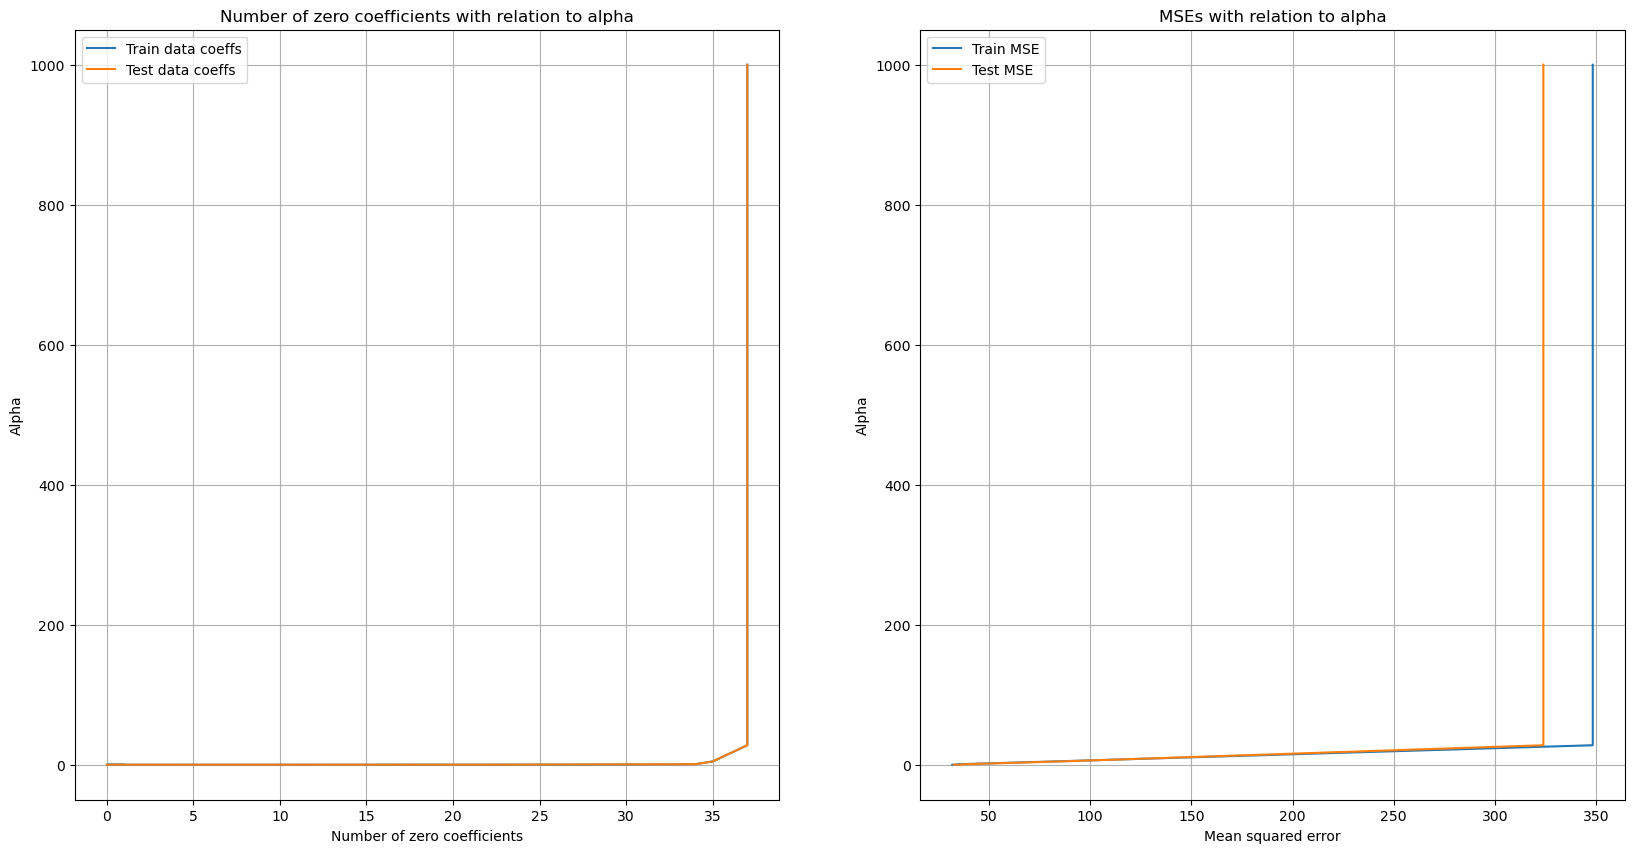

  Dataset: Previous Scores (out of 10) Sample Question Papers Practiced  \
0    Train          15.915367574585547                              0.0   
1     Test          15.146276582882798                              0.0   

       Hours Studied Hours Prepared for Exams       Hours Free time  \
0  6.450319580152821                      0.0  -0.12928615101790816   
1  6.352159693294794     0.030960291243186097                  -0.0   

  Sleep Hours Hours Not Sleep Height Weight   BMI Nails length  \
0         0.0            -0.0   -0.0   -0.0  -0.0          0.0   
1         0.0            -0.0    0.0    0.0   0.0          0.0   

  Extracurricular Activities_Yes Has a car_Not Given Has a car_Yes Sex_m  \
0                            0.0                 0.0           0.0   0.0   
1                           -0.0                 0.0           0.0   0.0   

  Eye color_blue Eye color_brown Eye color_gray Eye color_green  
0            0.0            -0.0            0.0            -0.0  


In [88]:
figure, ax = plt.subplots(1, 2, figsize = (20, 10))

ax[0].plot(coeffs_and_MSEs["Coefficients train"], coeffs_and_MSEs["Alphas"], label="Train data coeffs")
ax[0].plot(coeffs_and_MSEs["Coefficients test"], coeffs_and_MSEs["Alphas"], label="Test data coeffs")
ax[0].set_title('Number of zero coefficients with relation to alpha')
ax[0].set_xlabel('Number of zero coefficients')
ax[0].set_ylabel('Alpha')
ax[0].grid()
ax[0].legend()

ax[1].plot(coeffs_and_MSEs["MSE train"], coeffs_and_MSEs["Alphas"], label='Train MSE')
ax[1].plot(coeffs_and_MSEs["MSE test"],  coeffs_and_MSEs["Alphas"], label='Test MSE')
ax[1].set_title('MSEs with relation to alpha')
ax[1].set_xlabel('Mean squared error')
ax[1].set_ylabel('Alpha')
ax[1].grid()
ax[1].legend()

plt.show()

regr_train = Lasso(alpha=0.774264, tol = 0.1).fit(X_train, y_train)
regr_test = Lasso(alpha=0.774264, tol = 0.1).fit(X_test, y_test)
y_pred_train = regr_train.predict(X_train)
y_pred_test  = regr_test.predict(X_test)

X_train_and_test_coeffs = pd.DataFrame([ np.concatenate((["Train"], regr_train.coef_), axis = 0),
                            np.concatenate((["Test"], regr_test.coef_), axis = 0) ])
X_train_and_test_coeffs.columns = np.concatenate((["Dataset:"], feature_names), axis = 0)

print(X_train_and_test_coeffs.iloc[:, 0:20])
print(X_train_and_test_coeffs.iloc[:, 20:38])

**Answer** Since we were not asked to conduct cross-validation for Lasso regression in this task and were asked to conduct it for Ridge regression in the next one, we are limited to our grid that we have defined above in choosing the best Lambda in order to choose the most important features according to the Lasso regression results. The Lambda = 0.774264 from our grid seemed to be the best choice, since it had no significant change in MSE as compared to smaller alphas (as opposed to Lambda = 4.641589, which causes a big shift in MSE), and at the same time provided similar amount of important (not equal to 0) and unimportant (equal to 0) features as compared to the Linear Regression conducted above.
According to the results, the MSE for Lasso regression with the chosen value of Lambda is 35.719869 (for training dataset), while it was 31.822596840189018 for the Linear Regression conducted above. Smaller Lambdas bring results more similar MSE's to that of conducted Linear Regression. As for the important values identified by our Lasso regression, these are 'Previous Scores (out of 10)' (coefficient of 15.915367574585547 for training dataset), 'Hours Studied' (6.450319580152821) and 'Hours Free time' (-0.12928615101790816), which is similar to the results of Linear regression, although features 'Hours Prepared for Exams' and 'Favorite Subject_Data Science' are now considered to be unimportant (although 'Hours Prepared for Exams' is not equal to zero for Lasso regression conducted on the testing dataset and this should be considered important, but it is the results of regression on training dataset we should look with higher priority).

# Task 4 (2 points)

Now, use $L_2$ regularization. Tune hyperparameters of `Ridge` model  using cross-validation. Report the best MSE on test data.  

In [92]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

params = {'alpha' : np.logspace(-12, 10, 50)}

clf = GridSearchCV(Ridge(), params, cv=3, scoring='neg_mean_squared_error', verbose=7)
clf.fit(X_train, y_train)
best_param_train = clf.best_params_["alpha"]
print("\nBest MSE for train data is for alpha equal to", best_param_train, "\n")

clf = GridSearchCV(Ridge(), params, cv=3, scoring='neg_mean_squared_error', verbose=7)
clf.fit(X_test, y_test)
best_param_test = clf.best_params_["alpha"]
print("\nBest MSE for test data is for alpha equal to", best_param_test, "\n")

regr_train = Ridge(alpha=best_param_train).fit(X_train, y_train)
regr_test = Ridge(alpha=best_param_test).fit(X_test, y_test)
y_pred_train = regr_train.predict(X_train)
y_pred_test  = regr_test.predict(X_test)

print('Best MSE for test data is', mean_squared_error(y_test, y_pred_test))

Fitting 3 folds for each of 50 candidates, totalling 150 fits
[CV 1/3] END .....................alpha=1e-12;, score=-39.718 total time=   0.0s
[CV 2/3] END .....................alpha=1e-12;, score=-35.127 total time=   0.0s
[CV 3/3] END .....................alpha=1e-12;, score=-31.608 total time=   0.0s
[CV 1/3] END ....alpha=2.8117686979742253e-12;, score=-39.718 total time=   0.0s
[CV 2/3] END ....alpha=2.8117686979742253e-12;, score=-35.127 total time=   0.0s
[CV 3/3] END ....alpha=2.8117686979742253e-12;, score=-31.608 total time=   0.0s
[CV 1/3] END .....alpha=7.906043210907701e-12;, score=-39.718 total time=   0.0s
[CV 2/3] END .....alpha=7.906043210907701e-12;, score=-35.127 total time=   0.0s
[CV 3/3] END .....alpha=7.906043210907701e-12;, score=-31.608 total time=   0.0s
[CV 1/3] END .....alpha=2.222996482526191e-11;, score=-39.718 total time=   0.0s
[CV 2/3] END .....alpha=2.222996482526191e-11;, score=-35.127 total time=   0.0s
[CV 3/3] END .....alpha=2.222996482526191e-11;,

Investigate coefficients: how many zeros? Which features are important?

In [94]:
X_train_and_test_coeffs = pd.DataFrame([ np.concatenate((["Train"], regr_train.coef_), axis = 0),
                            np.concatenate((["Test"], regr_test.coef_), axis = 0) ])
X_train_and_test_coeffs.columns = np.concatenate((["Dataset:"], feature_names), axis = 0)

print(X_train_and_test_coeffs.iloc[:, 0:20])
print(X_train_and_test_coeffs.iloc[:, 20:38])

from sklearn.feature_selection import SelectFromModel

embeded_lr_selector = SelectFromModel(estimator=regr_train, threshold='4*median')
embeded_lr_support = embeded_lr_selector.get_support()
embeded_lr_feature = X_train.loc[:,embeded_lr_support].columns.tolist()
print(str(len(embeded_lr_feature)), 'selected features')
embeded_lr_feature

  Dataset: Previous Scores (out of 10) Sample Question Papers Practiced  \
0    Train           16.20207340934143             0.021177624036731388   
1     Test          15.379066117600665               0.6216124143325547   

       Hours Studied Hours Prepared for Exams       Hours Free time  \
0  5.992579086225725       0.9878132028823792  -0.38406169400215134   
1  4.879012203960454        1.802075313881123   -0.6186293854530208   

          Sleep Hours       Hours Not Sleep               Height  \
0  0.2418147963536772  -0.24181479635368397  -0.4169323201624285   
1    0.12101361078651  -0.12101361078650952   0.2762263896507449   

                Weight                  BMI         Nails length  \
0  -0.8476118395026462   0.5028990793882544  0.10263277426804462   
1   0.3285599537455523  0.23080873005351632  0.28819759638446624   

  Extracurricular Activities_Yes    Has a car_Not Given       Has a car_Yes  \
0              1.350065396491382     1.3599767458155902   0.84473143323

['Previous Scores (out of 10)',
 'Hours Studied',
 'Eye color_blue',
 'Favorite Subject_Data Science']

**Answer** The MSE for the best Lambda, as can be seen from the code output above, is 33.5954599164084 for the test dataset according to cross-validation for Ridge regression. To choose the important features, I have used the embedded method based on the Ridge regression conducted in the previous cell. The resulting set of important variables is corresponding to the biggest values of coefficients calculated by the Ridge regression model with the best Lambda. The important features are 'Previous Scores (out of 10)' (with coefficient of 16.20207340934143), 'Hours Studied' (5.992579086225725), 'Eye color_blue' (2.109911749861924), and 'Favorite Subject_Data Science' (2.0580125324408645). The first two sustainably appeared to be important thoughout all of our regression analysis (in Linear, Lasso and Ridge regressions) and make perfect sense. The 'Favorite Subject_Data Science' variable appeared as important in this Ridge regression as well as in Linear Regression (and was treated as unimportant by our Lasso regression), and its importance makes some sense due to the reasons described above. 'Eye color_blue' as an important variable in linear relationship to our dependent variable of 'Performance Index' makes little sense; but maybe, since blue is frequently considered to be the most beautiful and relatively rare eye color, this may signify that more attractive people do better in performance, which is logical, since student performance is closely related to personal communication.